In [1]:
import sys

# Remove wrong package path if present
sys.path = [p for p in sys.path if p != r"C:\Users\kapoo\agri\geoprep"]

# Put the correct source path first
sys.path.insert(0, r"C:\Users\kapoo\agri\src")

# Clear any cached geoprep imports
for mod in list(sys.modules):
    if mod.startswith("geoprep"):
        del sys.modules[mod]

In [2]:
# ==========================================
# Standard Library
# ==========================================
import os
import sys
import glob
from pathlib import Path

# ==========================================
# Scientific Computing
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import rasterio

# ==========================================
# Add GeoPrep to Python Path
# ==========================================
PROJECT_ROOT = r"C:\Users\kapoo\agri"
SRC_PATH = os.path.join(PROJECT_ROOT, "src")

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# ==========================================
# GeoPrep
# ==========================================
from geoprep.pipeline import GeoPrepPipeline
from geoprep.core.models import RasterScene

# ==========================================
# Initialize Pipeline
# ==========================================
pipeline = GeoPrepPipeline()

print("✅ GeoPrep imported successfully")
print("✅ Pipeline initialized")
print(pipeline)

✅ GeoPrep imported successfully
✅ Pipeline initialized


In [3]:
from geoprep.pipeline import GeoPrepPipeline

pipeline = GeoPrepPipeline()

print("SUCCESS")

SUCCESS


In [4]:
pipeline = GeoPrepPipeline()

print(pipeline)

In [5]:
folder = r"C:\Users\kapoo\agri\data\raw\sentinel2"

files = sorted(glob.glob(os.path.join(folder, "*.tif")))

print(f"Found {len(files)} files")

for f in files:
    print(os.path.basename(f))

Found 15 files
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_AOT.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B01.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B02.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B03.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B04.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B05.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B06.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B07.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B08.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B09.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B11.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B12.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_B8A.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_SCL.tif
S2B_MSIL2A_20250228T173149_R055_T14SLH_20250228T212633_WVP.tif


In [6]:
def get_band(code):
    return glob.glob(os.path.join(folder, f"*_{code}.tif"))[0]

paths = {
    "blue": get_band("B02"),
    "green": get_band("B03"),
    "red": get_band("B04"),
    "nir": get_band("B08"),
}

bands = {}

for name, path in paths.items():

    with rasterio.open(path) as src:

        bands[name] = src.read(1)

        if name == "red":

            crs = str(src.crs)
            resolution = float(src.res[0])

print("Loaded:")
for k, v in bands.items():
    print(k, v.shape)

Loaded:
blue (10980, 10980)
green (10980, 10980)
red (10980, 10980)
nir (10980, 10980)


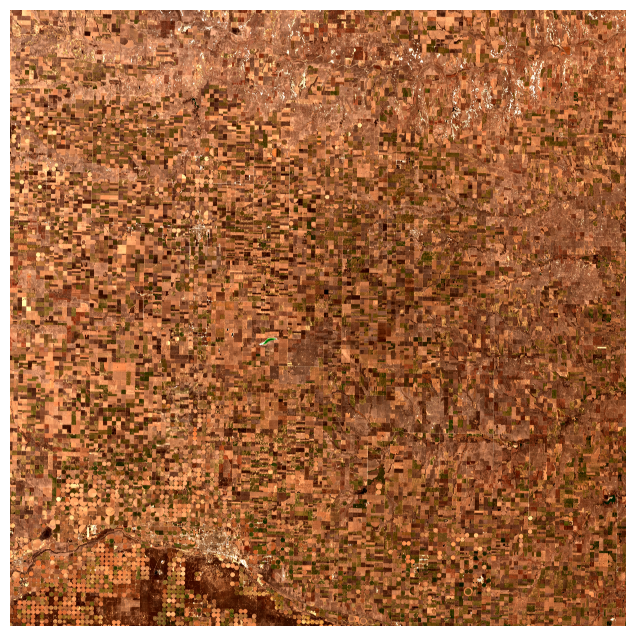

In [7]:
rgb = np.dstack([
    bands["red"],
    bands["green"],
    bands["blue"],
]).astype(np.float32)

low, high = np.percentile(rgb, (2, 98))

rgb = np.clip((rgb-low)/(high-low),0,1)

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.axis("off")
plt.show()

In [8]:
scene = RasterScene(
    scene_id="sentinel_test",
    modality="optical",
    acquisition_date="2025-02-28",
    crs=crs,
    resolution_m=resolution,
    bands=bands,
    cloud_mask=None,
    metadata={}
)

print(scene.band_names)
print(scene.band_shape())

['blue', 'green', 'red', 'nir']
(10980, 10980)


In [9]:
clean_scene = pipeline.preprocessing.preprocess_optical(
    scene=scene,
    target_crs=scene.crs,
    target_resolution_m=scene.resolution_m,
    target_shape=scene.band_shape(),
)

print(clean_scene)

{"level": "INFO", "logger": "geoprep.preprocessing", "message": "Preprocessing optical scene", "stage": "preprocess_optical", "timestamp": "2026-07-06T18:28:00"}


RasterScene(scene_id='sentinel_test', modality='optical', acquisition_date='2025-02-28', crs='EPSG:32614', resolution_m=10.0, bands={'blue': array([[0.1814    , 0.1866    , 0.18779999, ..., 0.1586    , 0.1566    ,
        0.1545    ],
       [0.18609999, 0.1858    , 0.18699999, ..., 0.15779999, 0.1594    ,
        0.1583    ],
       [0.1803    , 0.18439999, 0.1848    , ..., 0.1612    , 0.16129999,
        0.1594    ],
       ...,
       [0.20459999, 0.2092    , 0.2024    , ..., 0.14209999, 0.14039999,
        0.14479999],
       [0.2005    , 0.2082    , 0.20539999, ..., 0.1478    , 0.1548    ,
        0.1572    ],
       [0.19389999, 0.203     , 0.20699999, ..., 0.1812    , 0.181     ,
        0.1822    ]], shape=(10980, 10980), dtype=float32), 'green': array([[0.19919999, 0.20179999, 0.2032    , ..., 0.1742    , 0.173     ,
        0.1726    ],
       [0.2016    , 0.203     , 0.20359999, ..., 0.1749    , 0.17559999,
        0.1734    ],
       [0.20019999, 0.20459999, 0.20359999, ...

In [10]:
aligned = pipeline.alignment.align(
    optical_scenes=[clean_scene],
    sar_scenes=[],
)

print(aligned)

{"level": "INFO", "logger": "geoprep.alignment", "message": "Aligning observations", "stage": "align", "timestamp": "2026-07-06T18:28:14"}


[AlignedObservation(observation_id='sentinel_test__optical_only', acquisition_date='2025-02-28', optical=RasterScene(scene_id='sentinel_test', modality='optical', acquisition_date='2025-02-28', crs='EPSG:32614', resolution_m=10.0, bands={'blue': array([[0.1814    , 0.1866    , 0.18779999, ..., 0.1586    , 0.1566    ,
        0.1545    ],
       [0.18609999, 0.1858    , 0.18699999, ..., 0.15779999, 0.1594    ,
        0.1583    ],
       [0.1803    , 0.18439999, 0.1848    , ..., 0.1612    , 0.16129999,
        0.1594    ],
       ...,
       [0.20459999, 0.2092    , 0.2024    , ..., 0.14209999, 0.14039999,
        0.14479999],
       [0.2005    , 0.2082    , 0.20539999, ..., 0.1478    , 0.1548    ,
        0.1572    ],
       [0.19389999, 0.203     , 0.20699999, ..., 0.1812    , 0.181     ,
        0.1822    ]], shape=(10980, 10980), dtype=float32), 'green': array([[0.19919999, 0.20179999, 0.2032    , ..., 0.1742    , 0.173     ,
        0.1726    ],
       [0.2016    , 0.203     , 0.20

In [11]:
features = pipeline.features.generate(
    aligned
)

print(features)

{"level": "INFO", "logger": "geoprep.features", "message": "Generating features", "stage": "generate_for_observation", "timestamp": "2026-07-06T18:28:14"}


[FeatureCube(observation_id='sentinel_test__optical_only', acquisition_date='2025-02-28', crs='EPSG:32614', resolution_m=10.0, features={'ndvi': array([[0.09194098, 0.08465612, 0.08713384, ..., 0.13277175, 0.13241264,
        0.12459809],
       [0.09737825, 0.08441799, 0.08552136, ..., 0.12646462, 0.12998815,
        0.1294212 ],
       [0.09139374, 0.08374016, 0.09187146, ..., 0.13220873, 0.12896903,
        0.13232961],
       ...,
       [0.23561347, 0.22917238, 0.25144592, ..., 0.478484  , 0.45211312,
        0.42580256],
       [0.2583537 , 0.23305783, 0.2372042 , ..., 0.41720635, 0.37420332,
        0.35936546],
       [0.2864598 , 0.25054944, 0.23566529, ..., 0.24712469, 0.24238658,
        0.23630767]], shape=(10980, 10980), dtype=float32), 'evi': array([[0.08880931, 0.08353849, 0.0862765 , ..., 0.11905616, 0.11761307,
        0.10855484],
       [0.09678017, 0.08252744, 0.08446317, ..., 0.11238776, 0.11652618,
        0.11554883],
       [0.08785094, 0.08141065, 0.09040179, .

In [ ]:
dataset = pipeline.run_from_scenes(
    optical=[scene],
    sar=[],
    graph_nodes=[]
)

print(dataset)

{"level": "INFO", "logger": "geoprep.preprocessing", "message": "Preprocessing optical scene", "stage": "preprocess_optical", "timestamp": "2026-07-06T18:29:07"}


In [ ]:
import inspect

print(inspect.signature(pipeline.alignment.align))

In [ ]:
import inspect

print(inspect.signature(pipeline.model_inputs.prepare))